In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer



In [8]:
df=pd.read_csv('movie_reviews.csv')
df

,movie_title,rating,genre,in_theaters_date,movie_info,directors,director_gender,tomatometer_rating,audience_rating,critics_consensus
0,A Dog's Journey,PG,"Drama, Kids & Family",5/17/19,Bailey (voiced again by Josh Gad) is living th...,Gail Mancuso,female,50,92,A Dog's Journey is as sentimental as one might...
1,A Dog's Way Home,PG,Drama,1/11/19,"Separated from her owner, a dog sets off on an...",Charles Martin Smith,male,60,71,A Dog's Way Home may not quite be a family-fri...
2,A Tuba to Cuba,NR,"Documentary, Musical & Performing Arts",2/15/19,The leader of New Orleans' famed Preservation ...,"Danny Clinch, T.G. Herrington",male,100,82,NaN
3,A Vigilante,R,Drama,3/29/19,"A once abused woman, Sadie (Olivia Wilde), dev...",Sarah Daggar-Nickson,female,92,50,Led by Olivia Wilde's fearless performance and...
4,After,PG-13,"Drama, Romance",4/12/19,Based on Anna Todd's best-selling novel which ...,Jenny Gage,female,17,72,"Tepid and tired, After's fun flourishes are le..."
...,...,...,...,...,...,...,...,...,...,...
161,Velvet Buzzsaw,R,"Comedy, Drama, Mystery & Suspense",2/1/19,Velvet Buzzsaw is a satirical thriller set in ...,Dan Gilroy,male,63,36,If you only watch one art-world satire with ho...
162,What Men Want,R,Comedy,2/8/19,Inspired by the Nancy Meyers hit romantic come...,Adam Shankman,male,44,33,"Admittedly uneven but easy to like, What Men W..."
163,Wild Rose,R,"Comedy, Drama",6/21/19,WILD ROSE tells the complicated story of Rose-...,Tom Harper,male,93,88,"There's no shortage of star-is-born stories, b..."
164,Wine Country,R,Comedy,5/8/19,In honor of Rebecca (Rachel Dratch)'s 50th bir...,Amy Poehler,female,66,30,Wine Country's comedy might not be quite as ro...


In [11]:
sia=SentimentIntensityAnalyzer()

In [13]:
def sentimentAnalyzer(text):
    if isinstance(text, str):
        return sia.polarity_scores(text)['compound']
    return 0  # or np.nan if you prefer

In [14]:
df['reviewSentimentAnalysis']=df['critics_consensus'].apply(sentimentAnalyzer)

In [15]:
df[['movie_title','reviewSentimentAnalysis']]

,movie_title,reviewSentimentAnalysis
0,A Dog's Journey,0.0516
1,A Dog's Way Home,0.2402
2,A Tuba to Cuba,0.0000
3,A Vigilante,0.4404
4,After,0.1027
...,...,...
161,Velvet Buzzsaw,-0.5719
162,What Men Want,0.9207
163,Wild Rose,0.6868
164,Wine Country,0.8943


<Axes: ylabel='movie_title'>

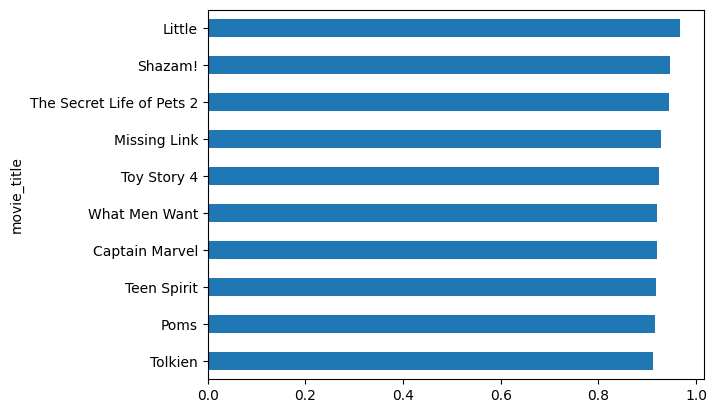

In [18]:
df.sort_values(by='reviewSentimentAnalysis', ascending=False)\
  .head(10)\
  .sort_values(by='reviewSentimentAnalysis')\
  .set_index('movie_title')['reviewSentimentAnalysis']\
  .plot(kind='barh')

<Axes: ylabel='movie_title'>

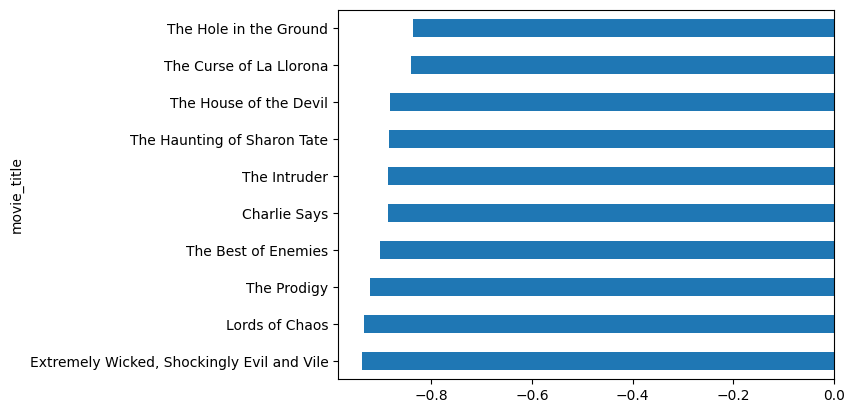

In [19]:
df.sort_values(by='reviewSentimentAnalysis', ascending=True)\
  .head(10)\
  .sort_values(by='reviewSentimentAnalysis')\
  .set_index('movie_title')['reviewSentimentAnalysis']\
  .plot(kind='barh')